In [1]:
import sys
sys.path.append("../../src")
sys.path.append("../../data")

import os
import numpy as np
from numba import njit
from scipy.stats import ortho_group
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from bss.PredictiveDecorrBSS_OlshaussenExp import PredictiveDecorrOlshaussen

# Read Image Patches

In [2]:
image_paths = '../../data/Olshaussen'
X_patches = scipy.io.loadmat(os.path.join(image_paths,'imagepatcheselfwhitened.mat'))['imagepatches']

In [3]:
X_patches.shape

(144, 312500)

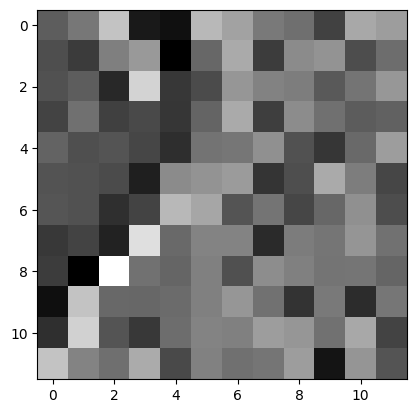

In [4]:
plt.imshow(X_patches[:, 0].reshape(12, 12), cmap = "gray")

# Hyperparameters

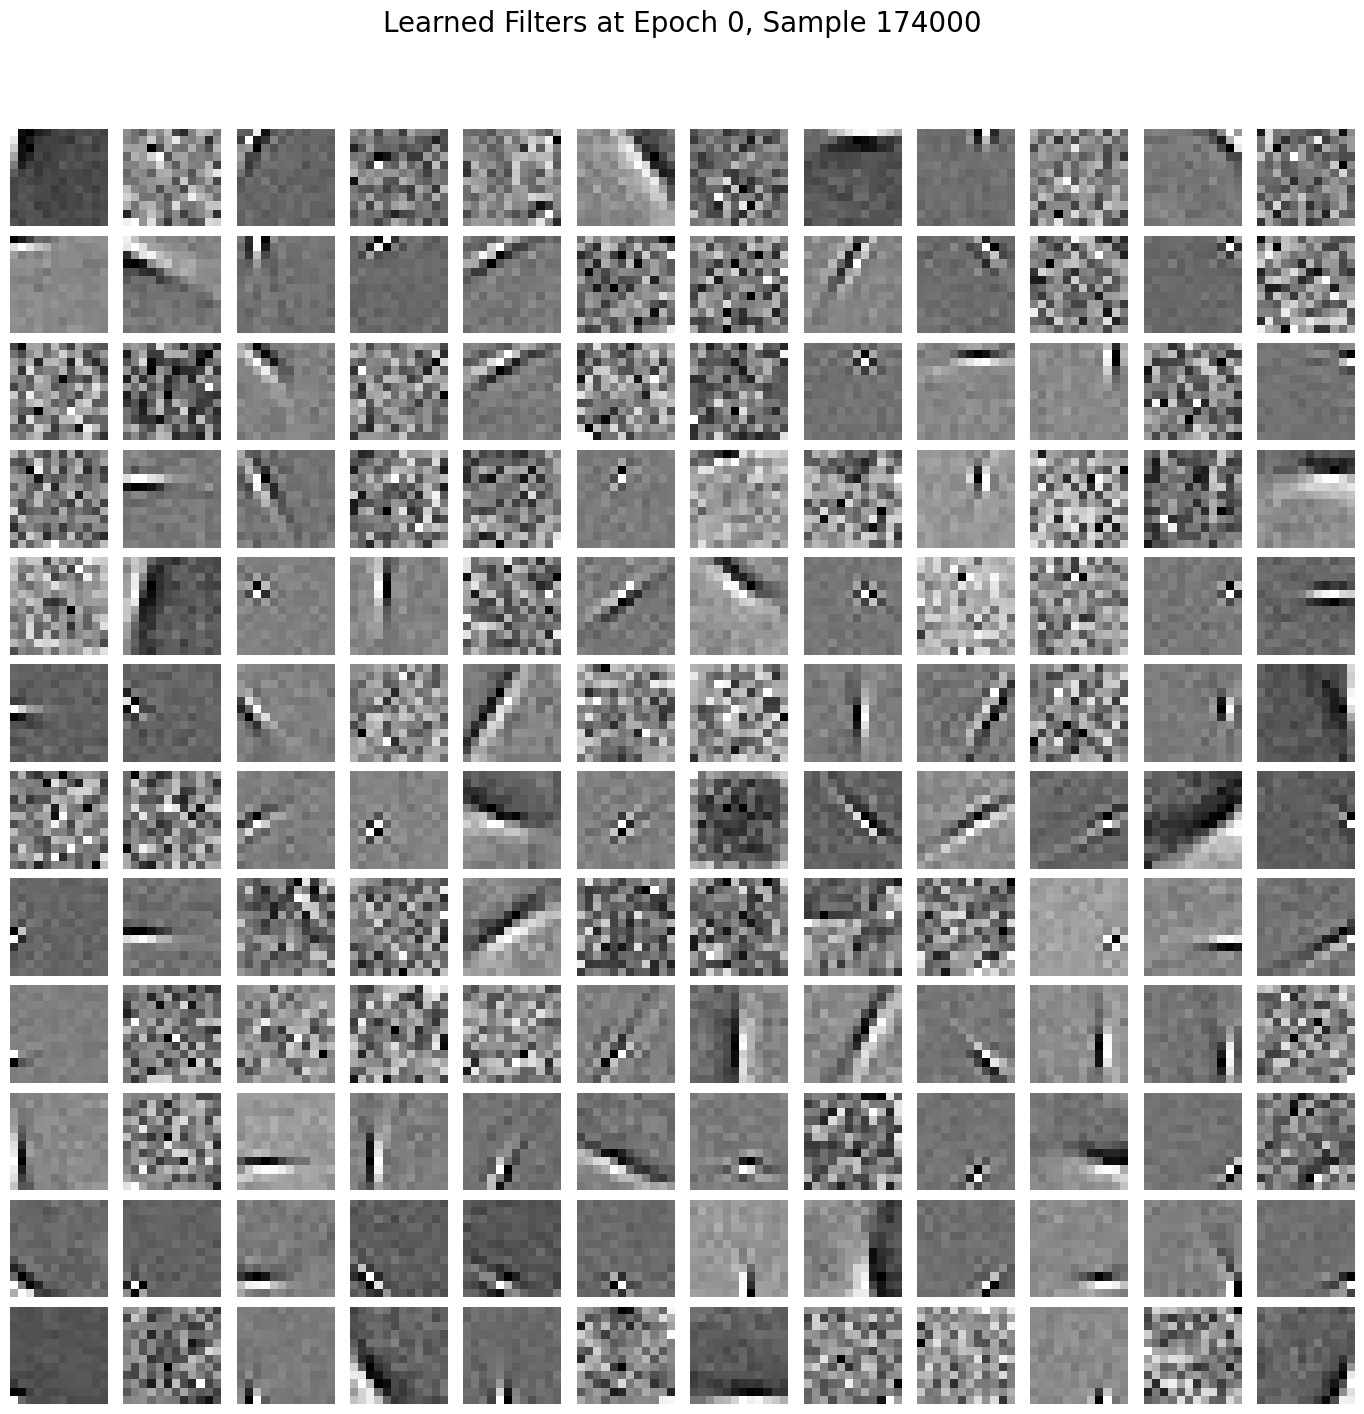

 56%|██████████████████████████████████████████████████▉                                        | 174987/312500 [18:45<09:32, 240.34it/s]

In [ ]:
seed = 0
np.random.seed(seed)
NumberofSources = 144
NumberofMixtures = 144
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 1 - 1e-3/7,
                "gamma_predictive" : 2,
                ### Learning rates 
                "lr_W" : 1e-3 / 4,
                "neural_lr_start" : 0.1,
                "neural_lr_stop" : 1e-6,
                "stlambda_lr" : 5e-3,
                "neural_dynamics_iterations" : 500,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "constant",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_slow_loop_index",
                "neural_lr_decay_divider" : 100,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : None,
                "debug_iteration_point" : 1000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrOlshaussen(**hyperparam_dict)
model.C_y = np.eye(NumberofSources) / 1. + np.random.randn(NumberofSources, NumberofSources) / 250
model.W = np.eye(NumberofSources, NumberofMixtures) * 1.0 + np.random.randn(NumberofSources, NumberofMixtures) / 250
model.fit(X_patches)

In [ ]:
display_matrix(model.C_y[:5, :5])

In [ ]:
display_matrix(model.mu_y.reshape(1, -1)[:, :5])

In [ ]:
display_matrix(model.W[:5, :5])

In [ ]:
lambdae = 1 - 1e-3 / 7
(1 - lambdae) / lambdae

In [ ]:
1.4e-4 * 20000